In [48]:
import random

import torch.nn as nn
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

In [49]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

In [50]:
transform = transforms.Compose([
    transforms.PILToTensor()
])

train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

classes = train_dataset.classes
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {classes}")

c:\Users\spisi\Documents\repos\computer-inteligence\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train samples: 50000
Test samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [51]:
def show(img, lbl):
    if torch.is_tensor(img):
        img = img.permute(1, 2, 0).cpu().numpy()

    label_name = classes[int(lbl)] if isinstance(lbl, (int, float)) or str(lbl).isdigit() else lbl

    plt.figure(figsize=(4, 4))
    plt.title(label_name, fontsize=12)
    plt.axis("off")
    plt.imshow(img)

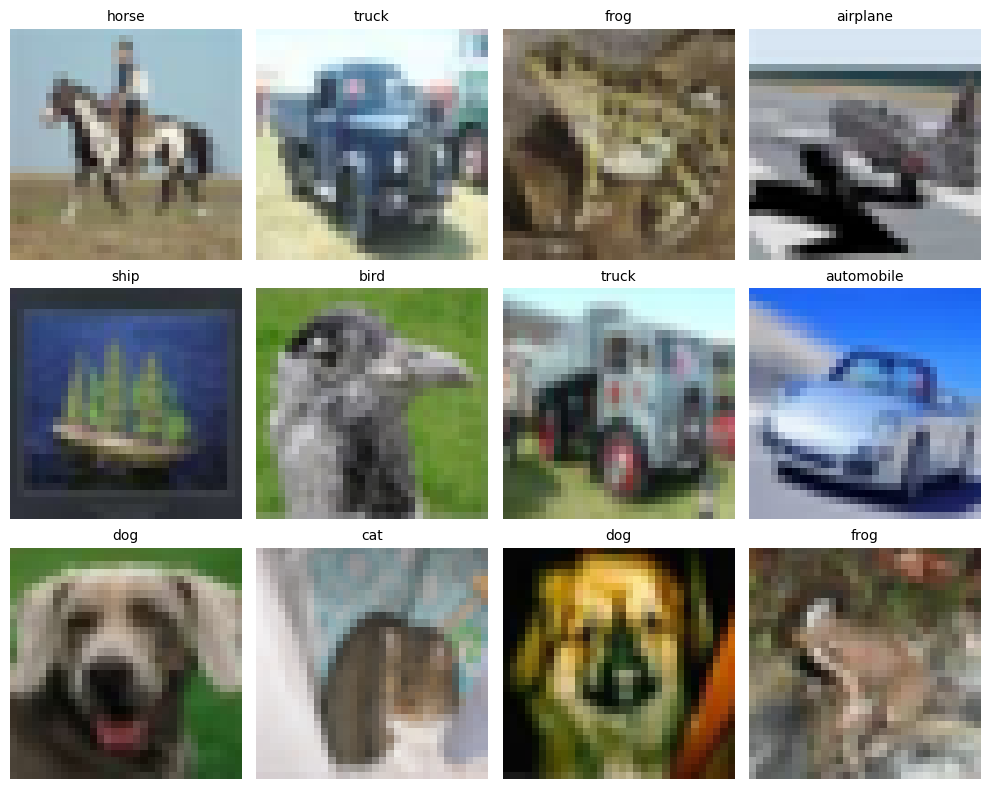

In [52]:
num_rows, num_cols = 3, 4
num_samples = num_rows * num_cols
sample_indices = random.sample(range(len(train_dataset)), num_samples)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 8))

for ax, idx in zip(axes.flatten(), sample_indices):
    image, label = train_dataset[idx]

    if torch.is_tensor(image):
        image = image.permute(1, 2, 0).cpu().numpy()

    ax.imshow(image)
    ax.set_title(classes[label], fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [53]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

In [54]:
def train(_model, _train_loader, _test_loader, _criterion, _optimizer, _num_epochs, device):
    _model.to(device)
    res = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
    }

    iterator = tqdm(range(_num_epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for X_batch, y_batch in _train_loader:
            X_batch = X_batch.to(device=device, dtype=torch.float32)
            y_batch = y_batch.to(device=device, dtype=torch.long)

            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            train_correct += (outputs.argmax(dim=1) == y_batch).sum().item()
            train_total += y_batch.size(0)

        epoch_train_loss = train_loss / train_total
        epoch_train_acc = train_correct / train_total

        _model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():
            for X_test, y_test in _test_loader:
                X_test = X_test.to(device=device, dtype=torch.float32)
                y_test = y_test.to(device=device, dtype=torch.long)

                test_outputs = _model(X_test)
                test_loss += _criterion(test_outputs, y_test).item() * X_test.size(0)
                test_correct += (test_outputs.argmax(dim=1) == y_test).sum().item()
                test_total += y_test.size(0)

        epoch_test_loss = test_loss / test_total
        epoch_test_acc = test_correct / test_total

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{epoch_train_acc:.4f}",
            test_loss=f"{epoch_test_loss:.4f}",
            test_acc=f"{epoch_test_acc:.4f}",
        )

        res["train_loss"].append(epoch_train_loss)
        res["train_acc"].append(epoch_train_acc)
        res["test_loss"].append(epoch_test_loss)
        res["test_acc"].append(epoch_test_acc)

    return res

In [55]:
def test(_model, _test_loader, _loss_function, device):
    _model.to(device)
    _model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for x, y in _test_loader:
            x = x.to(device=device, dtype=torch.float32)
            y = y.to(device=device, dtype=torch.long)

            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_correct += (output.argmax(dim=1) == y).sum().item()
            test_total += y.size(0)

    return (test_loss / test_total), (test_correct / test_total)

In [56]:
class CNN_1(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 25, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),

            nn.Conv2d(25, 50, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),

            nn.Conv2d(50, 75, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),

            nn.Flatten(),
            nn.Linear(75 * 4 * 4, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        return self.model(x)

In [57]:
# intermittent dropout
class CNN_2(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 25, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),

            nn.Conv2d(25, 50, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool2d(2, stride=2),

            nn.Conv2d(50, 75, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),

            nn.Conv2d(75, 100, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),

            nn.Flatten(),
            nn.Linear(100 * 4 * 4, 512),
            nn.Dropout(0.3),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        return self.model(x)

In [58]:
# With dropouts
class CNN_3(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 25, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool2d(2, stride=2),

            nn.Conv2d(25, 50, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool2d(2, stride=2),

            nn.Conv2d(50, 75, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool2d(2, stride=2),

            nn.Conv2d(75, 100, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool2d(2, stride=2),

            nn.Flatten(),
            nn.Linear(100 * 4 * 4, 512),
            nn.Dropout(0.3),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
num_epochs = 20
learning_rate = 1e-3
criterion = nn.CrossEntropyLoss()

model_builders = {
    "CNN_1": CNN_1,
    "CNN_2": CNN_2,
    "CNN_3": CNN_3,
}

histories = {}
final_metrics = {}
trained_models = {}

for name, model_builder in model_builders.items():
    print(f"\nTraining {name}:")
    model = model_builder()
    optimizer = Adam(model.parameters(), lr=learning_rate)

    history = train(
        model,
        train_loader,
        test_loader,
        criterion,
        optimizer,
        num_epochs,
        device,
    )
    test_loss, test_acc = test(model, test_loader, criterion, device)

    histories[name] = history
    trained_models[name] = model
    final_metrics[name] = {
        "test_loss": test_loss,
        "test_acc": test_acc,
    }

    print(f"{name} -> test_loss: {test_loss:.4f}, test_acc: {test_acc:.4f}")

pd.DataFrame(final_metrics).T.sort_values("test_acc", ascending=False)


Training CNN_1:


Training:  40%|████      | 8/20 [03:22<05:08, 25.67s/epoch, test_acc=0.6988, test_loss=0.9433, train_acc=0.7928, train_loss=0.5808]

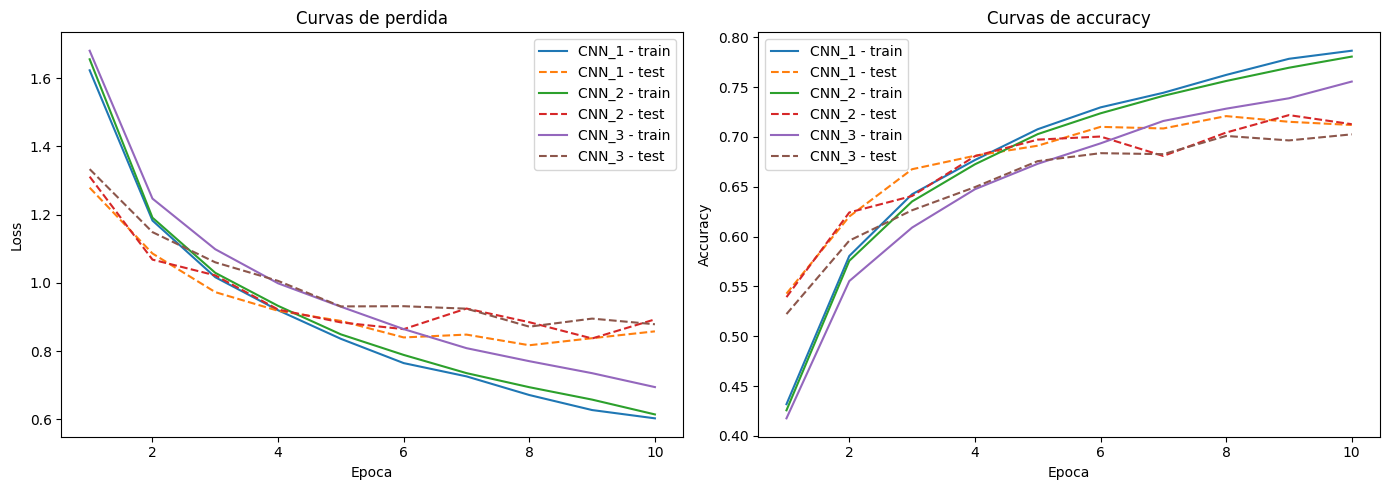

In [ ]:
def plot_learning_curves(_histories):
    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(14, 5))

    for name, hist in _histories.items():
        epochs = range(1, len(hist["train_loss"]) + 1)
        ax_loss.plot(epochs, hist["train_loss"], label=f"{name} - train")
        ax_loss.plot(epochs, hist["test_loss"], linestyle="--", label=f"{name} - test")
        ax_acc.plot(epochs, hist["train_acc"], label=f"{name} - train")
        ax_acc.plot(epochs, hist["test_acc"], linestyle="--", label=f"{name} - test")

    ax_loss.set_title("Curvas de perdida")
    ax_loss.set_xlabel("Epoca")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend()

    ax_acc.set_title("Curvas de accuracy")
    ax_acc.set_xlabel("Epoca")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.legend()

    plt.tight_layout()
    plt.show()


plot_learning_curves(histories)